In [32]:
from __future__ import annotations
import sys
sys.path.insert(0, "../../operon-project/code/graph_api")
sys.path.insert(0, "../../operon-project/code/search_pipeline")
sys.path.insert(0, "../")
from AMR_analysis.utils import _load_single_subgraph_pkl, load_functional_groups_file

from graph_classes import Subgraph, ReferenceGraph, MergedGraph, Edge, Node
from graph_classes import nameddict, count_fg_occurence, read_meta_data, get_graph_id, get_subgraph_id, \
    has_existing_graph_builds, delete_file, load_modified_from_pickle_if_exists, reset_subgraph_and_delete_modified
from graph_classes import ABUNDANCE_DETECTION_LIMIT, TXT_POSTFIX, JSON_POSTFIX, PICKLE_POSTFIX, MODIFIED_POSTFIX
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from matplotlib.lines import Line2D
import seaborn as sns

from __future__ import annotations

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from __future__ import annotations

from pathlib import Path
import pandas as pd

In [33]:
# Load Data

In [34]:


graphs_dir = Path('../data/runs/pfam_constrained_amr/window-size_10/min-contigs_3/min-domains-matched_1/graphs/')

graph_to_subgraph = {
    gf.name: _load_single_subgraph_pkl(gf)
    for gf in sorted(graphs_dir.glob("graph_*"))
    if gf.is_dir()
}

In [35]:
gc_nodes_to_integrase_path = Path('../data/runs/filtered_integrase_gc/functional_groups.txt')
gc_node_to_integrase = load_functional_groups_file(gc_nodes_to_integrase_path)

gc_nodes_to_AMR_path = Path('../data/runs/pfam_constrained_amr/functional_groups.txt')
gc_node_to_AMR = load_functional_groups_file(gc_nodes_to_AMR_path)

In [36]:
# Create table of prevalence per gc node per graph

In [37]:
# Build rows for: graph_id | gc_id | MatchType | ElementSymbol | RawPrevalence | RelativePrevalence

rows = []

for graph_key, sg in graph_to_subgraph.items():
    # graph_id: prefer helper if it works, otherwise fall back to folder name
    try:
        graph_id = get_graph_id(sg)
    except Exception:
        graph_id = graph_key

    gc_id_to_node = getattr(sg, "gc_id_to_node", None)
    if gc_id_to_node is None:
        raise AttributeError(f"Subgraph for {graph_key} has no attribute 'gc_id_to_node'")

    for gc_id, node in gc_id_to_node.items():
        matches = []
        if gc_id in gc_node_to_AMR:
            matches.append(("AMR", gc_node_to_AMR[gc_id]))
        if gc_id in gc_node_to_integrase:
            matches.append(("Integrase", gc_node_to_integrase[gc_id]))

        if not matches:
            continue

        abundance_annotation = getattr(node, "abundance_annotation", None)
        if abundance_annotation is None:
            raise AttributeError(f"Node for gc_id={gc_id} in graph={graph_id} has no 'abundance_annotation'")

        total_samples = len(abundance_annotation)
        raw_prevalence = 0
        for v in abundance_annotation.values():
            try:
                raw_prevalence += 1 if float(v) > 0 else 0
            except Exception:
                # If values are non-numeric, treat as not present
                raw_prevalence += 0

        relative_prevalence = (raw_prevalence / total_samples) if total_samples else 0.0

        for match_type, element_symbol in matches:
            if isinstance(element_symbol, (list, tuple, set)):
                element_symbol = ";".join(map(str, element_symbol))

            rows.append({
                "graph_id": graph_id,
                "gc_id": gc_id,
                "MatchType": match_type,
                "ElementSymbol": element_symbol,
                "RawPrevalence": raw_prevalence,
                "RelativePrevalence": relative_prevalence,
            })


In [38]:
# Build DataFrame
gc_match_prevalence_df = pd.DataFrame(rows)

gc_match_prevalence_df["graph_id"] = (
    gc_match_prevalence_df["graph_id"].astype(str)
    .str.replace(r"^(graph_)(\d)$", r"\g<1>0\g<2>", regex=True)
    .astype("category")
)

# Make appropriate columns categorical to save memory
categorical_cols = [
    "graph_id",
    "gc_id",
    "MatchType",
    "ElementSymbol",
]

for col in categorical_cols:
    if col in gc_match_prevalence_df.columns:
        gc_match_prevalence_df[col] = gc_match_prevalence_df[col].astype("category")

In [39]:
# Group by graph and get the mean amr relative and mean integrase relative prevalance
gc_match_prevalence_summary_df = gc_match_prevalence_df.groupby(
    ["graph_id", "MatchType"]
).agg(
    MeanRelativePrevalence=("RelativePrevalence", "mean"),
    MeanRawPrevalence=("RawPrevalence", "mean"),
    CountMatches=("gc_id", "nunique")
).reset_index()

/var/folders/21/f8bdlnrn6nd5jf2zc89bvz3m0000gn/T/ipykernel_26359/742246081.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gc_match_prevalence_summary_df = gc_match_prevalence_df.groupby(


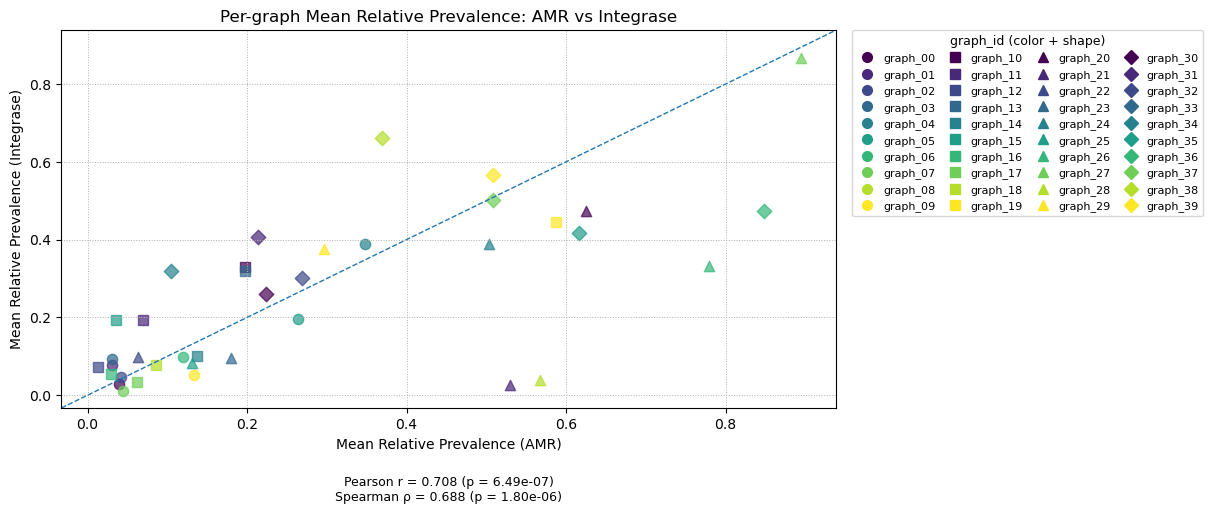

In [40]:
# Build per-graph wide table (AMR vs Integrase)
graph_mean_relative_prevalence_wide_df = (
    gc_match_prevalence_summary_df
    .pivot(index="graph_id", columns="MatchType", values="MeanRelativePrevalence")
    .rename(columns={"AMR": "MeanRelativePrevalence_AMR", "Integrase": "MeanRelativePrevalence_Integrase"})
    .reset_index()
    .dropna(subset=["MeanRelativePrevalence_AMR", "MeanRelativePrevalence_Integrase"])
)

# Parse numeric id for grouping (00-09, 10-19, 20-29, 30-39)
graph_mean_relative_prevalence_wide_df["graph_num"] = (
    graph_mean_relative_prevalence_wide_df["graph_id"].astype(str).str.extract(r"(\d+)$")[0].astype(int)
)
graph_mean_relative_prevalence_wide_df = graph_mean_relative_prevalence_wide_df.sort_values("graph_num")

# 10-step ordered palette reused per decade + marker encodes decade
base_cmap = plt.get_cmap("viridis")
ten_step_colors = [base_cmap(i / 9) for i in range(10)]
decade_to_marker = {0: "o", 1: "s", 2: "^", 3: "D"}  # 0-9, 10-19, 20-29, 30-39

# Plot points (no auto-legend labels)
fig, ax = plt.subplots(figsize=(10, 6))

base_cmap = plt.get_cmap("viridis")
ten_step_colors = [base_cmap(i / 9) for i in range(10)]
decade_to_marker = {0: "o", 1: "s", 2: "^", 3: "D"}  # 00-09, 10-19, 20-29, 30-39

for _, row in graph_mean_relative_prevalence_wide_df.iterrows():
    graph_num = int(row["graph_num"])
    decade = graph_num // 10
    within_decade = graph_num % 10

    ax.scatter(
        row["MeanRelativePrevalence_AMR"],
        row["MeanRelativePrevalence_Integrase"],
        s=55,
        alpha=0.7,
        marker=decade_to_marker.get(decade, "o"),
        color=ten_step_colors[within_decade],
    )

# y = x line
x_vals = graph_mean_relative_prevalence_wide_df["MeanRelativePrevalence_AMR"].to_numpy()
y_vals = graph_mean_relative_prevalence_wide_df["MeanRelativePrevalence_Integrase"].to_numpy()
pearson_r, pearson_p = pearsonr(x_vals, y_vals)
spearman_r, spearman_p = spearmanr(x_vals, y_vals)

correlation_text = (
    f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.2e})\n"
    f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.2e})"
)
ax.text(
    0.5, -0.18,
    correlation_text,
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=9,
)
min_val = float(min(x_vals.min(), y_vals.min()))
max_val = float(max(x_vals.max(), y_vals.max()))
pad = (max_val - min_val) * 0.05 if max_val > min_val else 0.05
line_min, line_max = (min_val - pad), (max_val + pad)
ax.plot([line_min, line_max], [line_min, line_max], linestyle="--", linewidth=1)

ax.set_xlim(line_min, line_max)
ax.set_ylim(line_min, line_max)
ax.set_xlabel("Mean Relative Prevalence (AMR)")
ax.set_ylabel("Mean Relative Prevalence (Integrase)")
ax.set_title("Per-graph Mean Relative Prevalence: AMR vs Integrase")
ax.grid(True, linestyle=":", linewidth=0.7)

# Legend that explicitly lists each graph_id with its marker + color
from matplotlib.lines import Line2D

graph_style_legend_handles = []
graph_style_legend_labels = []

for graph_num in range(40):
    graph_id = f"graph_{graph_num:02d}"
    decade = graph_num // 10
    within_decade = graph_num % 10

    graph_style_legend_handles.append(
        Line2D(
            [0], [0],
            marker=decade_to_marker.get(decade, "o"),
            linestyle="None",
            markerfacecolor=ten_step_colors[within_decade],
            markeredgecolor=ten_step_colors[within_decade],
            markersize=7,
        )
    )
    graph_style_legend_labels.append(graph_id)

ax.legend(
    handles=graph_style_legend_handles,
    labels=graph_style_legend_labels,
    title="graph_id (color + shape)",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    ncol=4,
    fontsize=8,
    title_fontsize=9,
    handletextpad=0.4,
    columnspacing=0.8,
)

fig.subplots_adjust(bottom=0.25)  # makes room for the correlation text under the axis labels
plt.show()



In [41]:
# Build a per-sample table:
# graph_id | sample_id | MeanAbundance_AMR | MeanAbundance_Integrase

rows = []

for graph_key, sg in graph_to_subgraph.items():
    try:
        graph_id = get_graph_id(sg)
    except Exception:
        graph_id = graph_key

    gc_id_to_node = getattr(sg, "gc_id_to_node", None)
    if gc_id_to_node is None:
        raise AttributeError(f"Subgraph for {graph_key} has no attribute 'gc_id_to_node'")

    amr_gc_ids = [gc_id for gc_id in gc_id_to_node.keys() if gc_id in gc_node_to_AMR]
    int_gc_ids = [gc_id for gc_id in gc_id_to_node.keys() if gc_id in gc_node_to_integrase]

    # keep only graphs where both exist (since you want AMR vs Integrase)
    if not amr_gc_ids or not int_gc_ids:
        continue

    # union of sample ids across the involved nodes (robust to missing keys)
    sample_ids = set()
    for gc_id in amr_gc_ids + int_gc_ids:
        ann = getattr(gc_id_to_node[gc_id], "abundance_annotation", None)
        if ann is None:
            raise AttributeError(f"Node for gc_id={gc_id} in graph={graph_id} has no 'abundance_annotation'")
        sample_ids.update(ann.keys())

    for sample_id in sample_ids:
        amr_vals = []
        for gc_id in amr_gc_ids:
            v = gc_id_to_node[gc_id].abundance_annotation.get(sample_id, 0)
            try:
                amr_vals.append(float(v))
            except Exception:
                amr_vals.append(0.0)

        int_vals = []
        for gc_id in int_gc_ids:
            v = gc_id_to_node[gc_id].abundance_annotation.get(sample_id, 0)
            try:
                int_vals.append(float(v))
            except Exception:
                int_vals.append(0.0)

        rows.append(
            {
                "graph_id": str(graph_id),
                "sample_id": str(sample_id),
                "MeanAbundance_AMR": float(np.mean(amr_vals)) if amr_vals else np.nan,
                "MeanAbundance_Integrase": float(np.mean(int_vals)) if int_vals else np.nan,
            }
        )

sample_abundance_df = pd.DataFrame(rows).dropna(subset=["MeanAbundance_AMR", "MeanAbundance_Integrase"])

# graph_num for styling (expects suffix digits like graph_00 ... graph_39)
sample_abundance_df["graph_num"] = (
    sample_abundance_df["graph_id"].str.extract(r"(\d+)$")[0].astype(int)
)
sample_abundance_df = sample_abundance_df.sort_values(["graph_num", "sample_id"])

# style maps (same as your previous scheme)
base_cmap = plt.get_cmap("viridis")
ten_step_colors = [base_cmap(i / 9) for i in range(10)]
decade_to_marker = {0: "o", 1: "s", 2: "^", 3: "D"}  # 00-09, 10-19, 20-29, 30-39

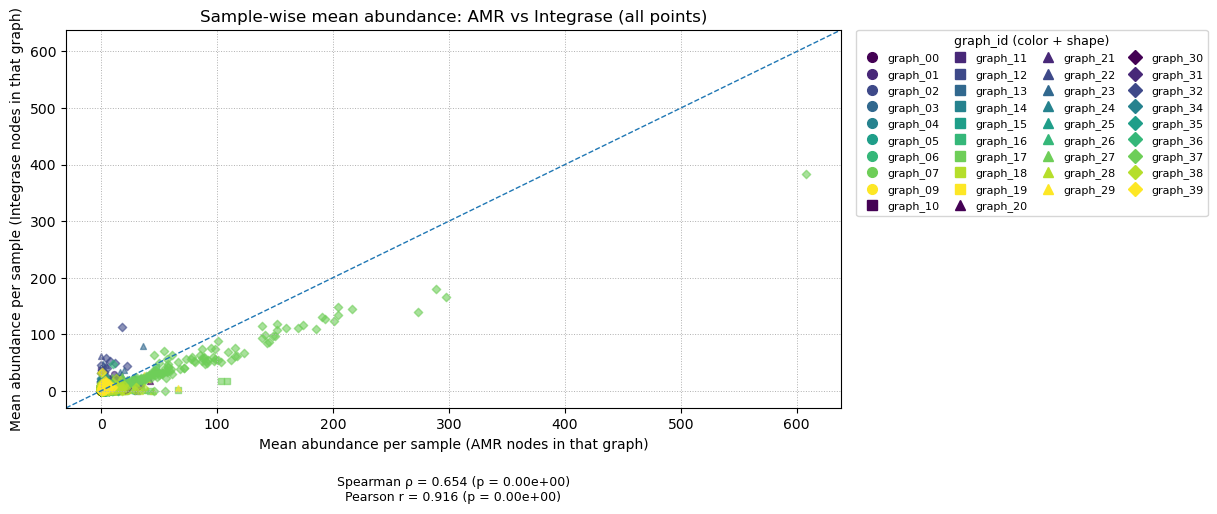

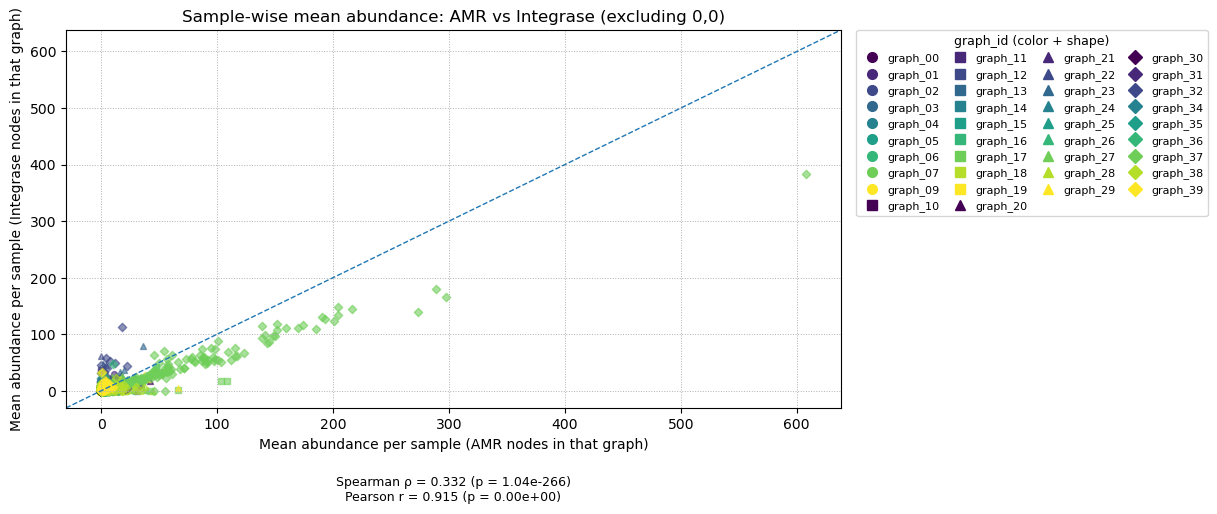

In [42]:
def plot_sample_scatter_fast(df: pd.DataFrame, drop_zero_zero: bool, title: str) -> None:
    if drop_zero_zero:
        d = df.loc[~((df["MeanAbundance_AMR"] == 0) & (df["MeanAbundance_Integrase"] == 0))].copy()
    else:
        d = df.copy()

    # correlations (can be the slow part if you have huge N)
    x = d["MeanAbundance_AMR"].to_numpy(dtype=float)
    y = d["MeanAbundance_Integrase"].to_numpy(dtype=float)

    spearman_r, spearman_p = spearmanr(x, y)
    pearson_r, pearson_p = pearsonr(x, y)

    fig, ax = plt.subplots(figsize=(10, 6))

    # scatter in <= 40 calls (one per graph_num)
    for gnum, g in d.groupby("graph_num", sort=True):
        gnum = int(gnum)
        decade = gnum // 10
        within = gnum % 10
        ax.scatter(
            g["MeanAbundance_AMR"].to_numpy(),
            g["MeanAbundance_Integrase"].to_numpy(),
            s=18,
            alpha=0.6,
            marker=decade_to_marker.get(decade, "o"),
            color=ten_step_colors[within],
            rasterized=True,  # big speed-up for large point clouds (esp. when saving)
        )

    # y = x line (based on visible points)
    if len(x) > 0:
        min_val = float(min(x.min(), y.min()))
        max_val = float(max(x.max(), y.max()))
        pad = (max_val - min_val) * 0.05 if max_val > min_val else 0.05
        line_min, line_max = (min_val - pad), (max_val + pad)
        ax.plot([line_min, line_max], [line_min, line_max], linestyle="--", linewidth=1)
        ax.set_xlim(line_min, line_max)
        ax.set_ylim(line_min, line_max)

    ax.set_xlabel("Mean abundance per sample (AMR nodes in that graph)")
    ax.set_ylabel("Mean abundance per sample (Integrase nodes in that graph)")
    ax.set_title(title)
    ax.grid(True, linestyle=":", linewidth=0.7)

    corr_text = (
        f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.2e})\n"
        f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.2e})"
    )
    ax.text(0.5, -0.18, corr_text, transform=ax.transAxes, ha="center", va="top", fontsize=9)

    # legend: only graphs present
    present_graph_nums = sorted(d["graph_num"].unique().tolist())
    handles, labels = [], []
    for gnum in present_graph_nums:
        decade = gnum // 10
        within = gnum % 10
        handles.append(
            Line2D(
                [0], [0],
                marker=decade_to_marker.get(decade, "o"),
                linestyle="None",
                markerfacecolor=ten_step_colors[within],
                markeredgecolor=ten_step_colors[within],
                markersize=7,
            )
        )
        labels.append(f"graph_{gnum:02d}")
    ax.legend(
        handles=handles,
        labels=labels,
        title="graph_id (color + shape)",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        ncol=4,
        fontsize=8,
        title_fontsize=9,
        handletextpad=0.4,
        columnspacing=0.8,
    )

    fig.subplots_adjust(bottom=0.25)
    plt.show()
plot_sample_scatter_fast(
    sample_abundance_df,
    drop_zero_zero=False,
    title="Sample-wise mean abundance: AMR vs Integrase (all points)",
)

plot_sample_scatter_fast(
    sample_abundance_df,
    drop_zero_zero=True,
    title="Sample-wise mean abundance: AMR vs Integrase (excluding 0,0)",
)

In [43]:
# Calculate the spearman correlations for each graph individually, so basically I would want a table with graph_id | spearman_r | spearman_p
# graph_id | spearman_r | spearman_p (computed within each graph)
spearman_by_graph_df = (
    sample_abundance_df
    .groupby("graph_id", sort=True)
    .apply(lambda g: pd.Series(
        spearmanr(g["MeanAbundance_AMR"].to_numpy(dtype=float),
                  g["MeanAbundance_Integrase"].to_numpy(dtype=float)),
        index=["spearman_r", "spearman_p"],
    ))
    .reset_index()
)
spearman_by_graph_df['log10_spearman_p'] = -np.log10(spearman_by_graph_df['spearman_p'].replace(0, np.nextafter(0, 1)))

/var/folders/21/f8bdlnrn6nd5jf2zc89bvz3m0000gn/T/ipykernel_26359/1834018873.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series(


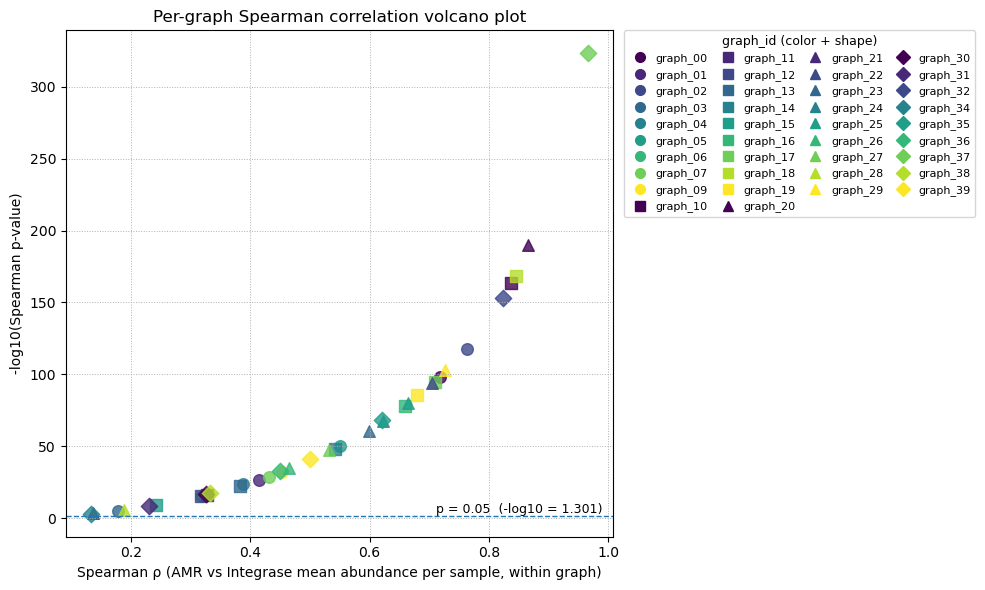

In [45]:
# Ensure graph_num exists (for decade marker + within-decade color)
spearman_by_graph_df["graph_num"] = (
        spearman_by_graph_df["graph_id"].astype(str).str.extract(r"(\d+)$")[0].astype(int)
    )

# Same styling scheme as before
base_cmap = plt.get_cmap("viridis")
ten_step_colors = [base_cmap(i / 9) for i in range(10)]
decade_to_marker = {0: "o", 1: "s", 2: "^", 3: "D"}  # 00-09, 10-19, 20-29, 30-39

# Volcano plot: x = Spearman rho, y = -log10(p)
d = spearman_by_graph_df.dropna(subset=["spearman_r", "log10_spearman_p", "graph_num"]).copy()
d = d.sort_values("graph_num")

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in d.iterrows():
    gnum = int(row["graph_num"])
    decade = gnum // 10
    within = gnum % 10
    ax.scatter(
        row["spearman_r"],
        row["log10_spearman_p"],
        s=70,
        alpha=0.8,
        marker=decade_to_marker.get(decade, "o"),
        color=ten_step_colors[within],
    )

# Significance threshold line at p=0.05
sig_y = -np.log10(0.05)
ax.axhline(sig_y, linestyle="--", linewidth=1)
ax.text(
    0.98, sig_y,
    f"p = 0.05  (-log10 = {sig_y:.3f})",
    ha="right", va="bottom",
    transform=ax.get_yaxis_transform(),
    fontsize=9,
)

ax.set_xlabel("Spearman ρ (AMR vs Integrase mean abundance per sample, within graph)")
ax.set_ylabel("-log10(Spearman p-value)")
ax.set_title("Per-graph Spearman correlation volcano plot")
ax.grid(True, linestyle=":", linewidth=0.7)

# Legend: one entry per graph_id (color + shape)
handles, labels = [], []
for gnum in d["graph_num"].astype(int).tolist():
    decade = gnum // 10
    within = gnum % 10
    handles.append(
        Line2D(
            [0], [0],
            marker=decade_to_marker.get(decade, "o"),
            linestyle="None",
            markerfacecolor=ten_step_colors[within],
            markeredgecolor=ten_step_colors[within],
            markersize=7,
        )
    )
    labels.append(f"graph_{gnum:02d}")

ax.legend(
    handles=handles,
    labels=labels,
    title="graph_id (color + shape)",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    ncol=4,
    fontsize=8,
    title_fontsize=9,
    handletextpad=0.4,
    columnspacing=0.8,
)

plt.tight_layout()
plt.show()

In [46]:
spearman_by_graph_df

,graph_id,spearman_r,spearman_p,log10_spearman_p,graph_num
0,graph_0,0.718536,6.565295e-99,98.182746,0
1,graph_1,0.414564,4.170220e-27,26.379841,1
2,graph_10,0.837468,1.393527e-164,163.855885,10
3,graph_11,0.327801,4.517132e-17,16.345137,11
4,graph_12,0.317657,5.590909e-16,15.252518,12
5,graph_13,0.382608,2.518606e-23,22.598840,13
6,graph_14,0.541104,6.725420e-49,48.172281,14
7,graph_15,0.241496,1.051969e-09,8.977997,15
8,graph_16,0.660142,2.399865e-78,77.619813,16
9,graph_17,0.709006,4.710797e-95,94.326906,17
